In [56]:
from __future__ import print_function, division
import sys,os
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
%matplotlib inline 
font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font) 

figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"

U_max = 8.0
V_max = 6.0
        
N_Points = 50
L = 5

In [57]:
def load_data(L, U_max, V_max, N_Points, U_min = -U_max, V_min = -V_max, min_vals = False):
    
    # Generate discretized U and V values
    U_vals = np.loadtxt(f"{results}/{model}_{exec}/U_vals_NPoints={N_Points}.txt")
    V_vals = np.loadtxt(f"{results}/{model}_{exec}/V_vals_NPoints={N_Points}.txt")

    U_vals = np.array(U_vals)
    V_vals = np.array(V_vals)

    magnetization = np.zeros((N_Points, N_Points, L))
    charge_density = np.zeros((N_Points, N_Points, L))
    doublons = np.zeros((N_Points, N_Points, L))

    energy = np.zeros((N_Points, N_Points))
    E_p = np.zeros((N_Points, N_Points))

    # Loop over U and V values
    for i, U_f in enumerate(U_vals):
        for j, V_f in enumerate(V_vals):
            info_output = f"{results}/{model}_{exec}/XXXXX_{model}_L={L}_U={U_f}_V={V_f}_NPoints={N_Points}.txt"

            str_magnetization = info_output.replace('XXXXX', 'magnetization')
            str_charge_density = info_output.replace('XXXXX', 'charge_density')
            str_doublons = info_output.replace('XXXXX', 'doublons')


            str_energy = info_output.replace('XXXXX', 'E_GS')
            energy[i, j] = np.loadtxt(str_energy)

            E_p_str = info_output.replace('XXXXX', 'E_p')
            E_p[i, j] = np.loadtxt(E_p_str)

            magnetization[i, j] = np.loadtxt(str_magnetization)
            charge_density[i, j] = np.loadtxt(str_charge_density)
            doublons[i, j] = np.loadtxt(str_doublons)

    return magnetization, charge_density, doublons, energy, E_p, U_vals, V_vals

In [58]:
def m_SDW(L, Sj): 
    m_sdw = 0
    for j in range(L):
        m_sdw += (-1)**(j) * (Sj[j])
    return m_sdw / L

def m_CDW(L, nj):
    m_cdw = 0
    for j in range(L):
        m_cdw += (-1)**(j) * (nj[j] - 1)
    return m_cdw / L 

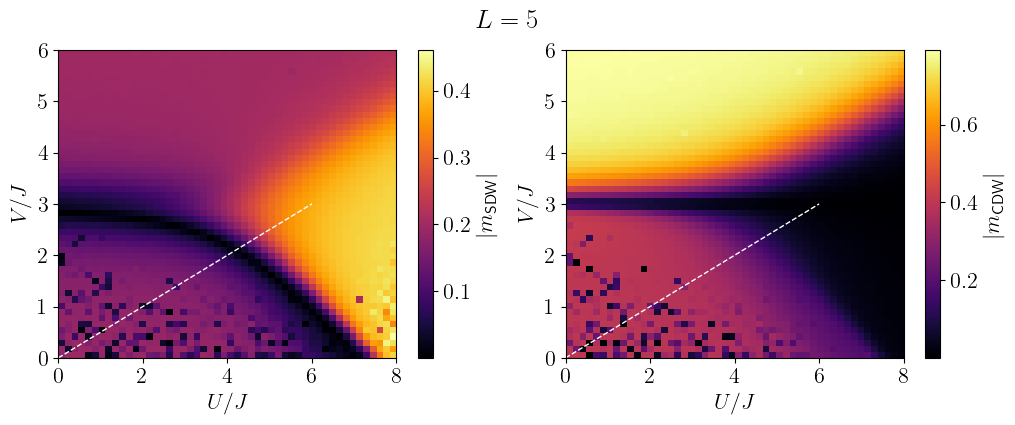

In [59]:
magnetization, charge_density, _, _, _, U_vals, V_vals = load_data(L, U_max, V_max, N_Points, min_vals=True)

m_sdw = np.zeros((N_Points, N_Points))
m_cdw = np.zeros((N_Points, N_Points))

for i, U in enumerate(U_vals):
    for j, V in enumerate(V_vals):

        magnetization_ij = magnetization[i, j]
        charge_density_ij = charge_density[i, j]

        m_sdw[i, j] = np.abs(m_SDW(L, magnetization_ij))
        m_cdw[i, j] = np.abs(m_CDW(L, charge_density_ij))

# The data in m_sdw and m_cdw are transposed!
m_sdw = m_sdw.T 
m_cdw = m_cdw.T

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
plt.suptitle(f"$L = {L}$")

# Plot m_SDW heatmap
im0 = ax[0].imshow(m_sdw, origin="lower", extent=[0, U_max, 0, V_max], aspect="auto", cmap="inferno")
fig.colorbar(im0, ax=ax[0], label=r"$|m_{\text{SDW}}|$")
ax[0].set_xlabel(r"$U / J$")
ax[0].set_ylabel(r"$V / J$")
#ax[0].set_title(r"$m_{\text{SDW}}=(1/L) \sum_{j}(-1)^j \langle \hat{S}_{j}^{z} \rangle$")

# Plot m_CDW heatmap
im1 = ax[1].imshow(m_cdw, origin="lower", extent=[0, U_max, 0, V_max], aspect="auto", cmap="inferno")
fig.colorbar(im1, ax=ax[1] , label=r"$|m_{\text{CDW}}|$")
ax[1].set_xlabel(r"$U / J$")
ax[1].set_ylabel(r"$V / J$")
#ax[1].set_title(r"$m_{\text{CDW}}=(1/L)\sum_{j}(-1)^j (\langle \hat{n}_j \rangle-1)$")

# Plot line U = 2V
V_range = np.linspace(0, V_max / 2, N_Points)
U_range = 2 * V_range 
ax[0].plot(U_range, V_range, 'w--', linewidth=1)
ax[1].plot(U_range, V_range, 'w--', linewidth=1)

# Save the figure
# plt.savefig(f"{figures_path}/{model}_{exec}/order_parameters_L={L}_Npoints={N_Points}_Umax={U_max}_Vmax={V_max}.png", dpi=300, bbox_inches="tight")
plt.show()

- Energy


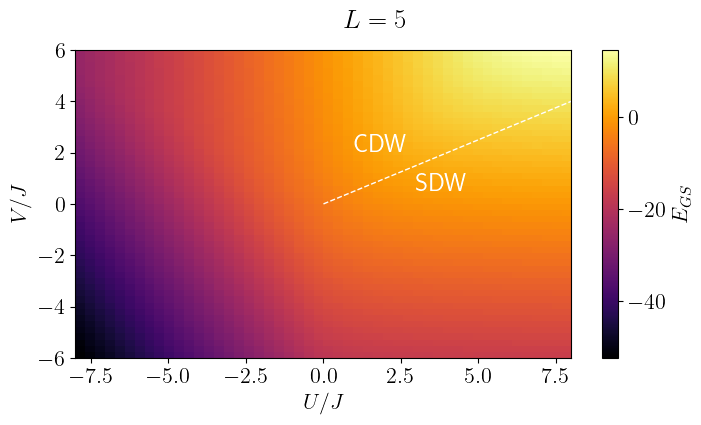

In [60]:
Ls = [5]

U_min = -U_max 
V_min = -V_max
for L in Ls:
    _, _, _, energy, _, U_vals, V_vals = load_data(L, U_max, V_max, N_Points)
    # Create a figure with two subplots
    fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharex=True)
    im0 = ax.imshow(energy, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="inferno")
    fig.colorbar(im0, ax=ax, label=r"$E_{GS}$")
    ax.set_xlabel(r"$U / J$")
    ax.set_ylabel(r"$V / J$")

    # Plot line U = 2V
    V_range = np.linspace(0, U_max / 2, N_Points)
    U_range = 2 * V_range 
    ax.plot(U_range, V_range, 'w--', linewidth=1)  
    
    ax.text(1, 2, "$\\text{CDW}$", color = "white", fontsize=18)
    ax.text(3, 0.5, "$\\text{SDW}$", color = "white", fontsize=18)
    
    plt.suptitle(f"$L = {L}$")
    plt.show()
    fig.savefig(f"{figures_path}/{model}_{exec}/E_GS={L}_{model}_NPoints={N_Points}.png", dpi = 500, bbox_inches='tight')


[[0.24105324 0.20533095 0.35256078 ... 0.16072182 0.15914856 0.23971808]
 [0.21356207 0.38271321 0.22803776 ... 0.09311397 0.1858504  0.22265897]
 [0.17877171 0.15564993 0.19952338 ... 0.19397889 0.15896657 0.17502083]
 ...
 [0.53180223 0.49575578 0.4884461  ... 0.36387215 0.34434219 0.32928837]
 [0.47934962 0.46572662 0.44363417 ... 0.3766835  0.35525388 0.33768065]
 [0.45605347 0.46443018 0.44411115 ... 0.39123149 0.3671376  0.34729409]]


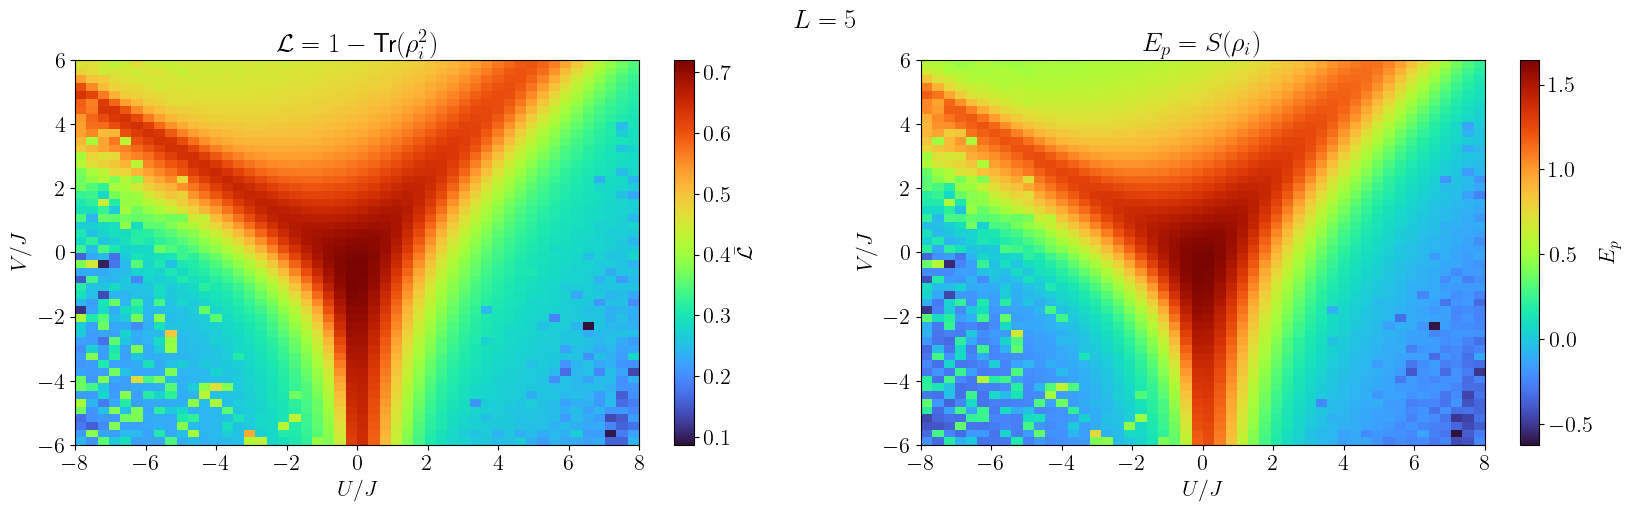

In [73]:
magnetization = np.zeros((N_Points, N_Points, L))
charge_density = np.zeros((N_Points, N_Points, L))

magnetization, charge_density, doublons, _, E_p,  U_vals, V_vals = load_data(L, U_max, V_max, N_Points)

nup = (magnetization + charge_density) / 2
ndn = -(magnetization - charge_density) / 2

avg_linear_entropy = np.zeros((N_Points, N_Points))

for i, U_f in enumerate(U_vals):
    for j, V_f in enumerate(V_vals):

        # print(f"(U, V) = ({U_f}, {V_f})")

        nupdn_k = doublons[i, j]
        nup_k = nup[i, j]
        ndn_k = ndn[i, j]

        linear_entropy_k = np.zeros(L)

        for k in range(L):

            w_2 = nupdn_k[k]
            w_up = nup_k[k] - w_2 
            w_dn = ndn_k[k] - w_2 
            w_0 = 1 - w_up - w_dn - w_2 

            # print(f"w_2 = {w_2}")
            # print(f"w_up = {w_up}")
            # print(f"w_dn = {w_dn}")
            # print(f"w_0 = {w_0}")
            
            # print(f"Tr(rho^2) = {(w_2**2 + w_up**2 + w_dn**2 + w_0**2)}")

            linear_entropy_k[k]  = 1 - (w_2**2 + w_up**2 + w_dn**2 + w_0**2)

        avg_linear_entropy[i, j] = np.mean(linear_entropy_k)

print(avg_linear_entropy)

# Create a figure with two subplots
fig, ax1 = plt.subplots(1, 2, figsize=(20, 5))
plt.suptitle(f"$L = {L}$")

# Shared colorbar normalization - thanks chatgpt
# vmin = min(np.min(linear_entropy), np.min(E_p))
# vmax = max(np.max(linear_entropy), np.max(E_p))

U_min = -U_max 
V_min = -V_max


im0 = ax1[0].imshow(avg_linear_entropy, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="turbo") # , vmin=vmin, vmax=vmax)
fig.colorbar(im0, ax = ax1[0], orientation='vertical', shrink=1.0, label=r"$\bar{\mathcal{L}}$")

im1 = ax1[1].imshow(L//2 * E_p - np.log2(L//2), origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="turbo") # , vmin=vmin, vmax=vmax)
fig.colorbar(im1, ax = ax1[1], orientation='vertical', shrink=1.0, label=r"$E_p$")

# bar = plt.colorbar(im0, orientation='vertical', shrink=0.8, label=r"$E_p$") 
ax1[0].set_xlabel(r"$U / J$")
ax1[0].set_ylabel(r"$V / J$")

ax1[1].set_xlabel(r"$U / J$")
ax1[1].set_ylabel(r"$V / J$")

ax1[0].set_title(r"$\mathcal{L} = 1 - \text{Tr}(\rho_i^2)$")
ax1[1].set_title(r"$E_p = S(\rho_i)$")

# fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_entropy_1_RDM={L}.png", dpi=100, bbox_inches='tight')
plt.show()